In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

In [2]:
df = pd.read_csv("wine.csv")

In [ ]:
df

In [3]:
# Fix column names
df.columns = df.columns.str.replace(" ", "_")

In [7]:
features = df.drop("quality", axis=1).columns.to_list()

<Axes: xlabel='quality', ylabel='Density'>

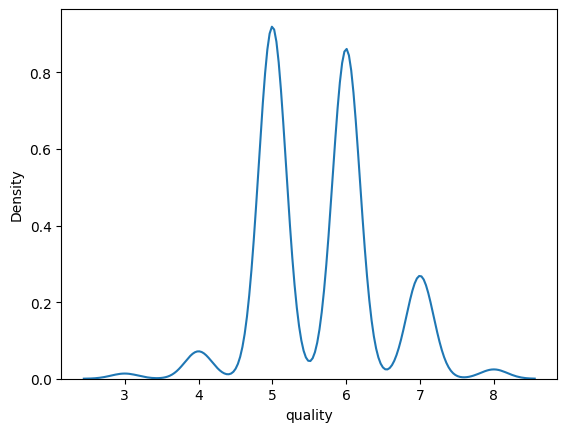

In [24]:
# Target variable distribution
sns.kdeplot(df["quality"])

<Axes: >

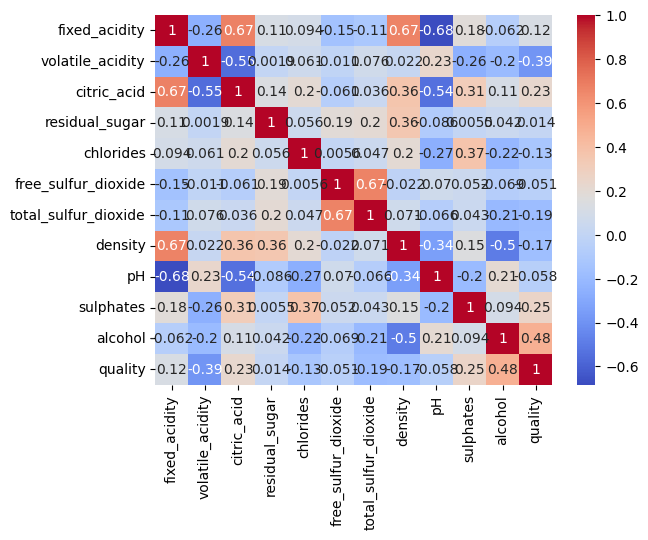

In [25]:
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)

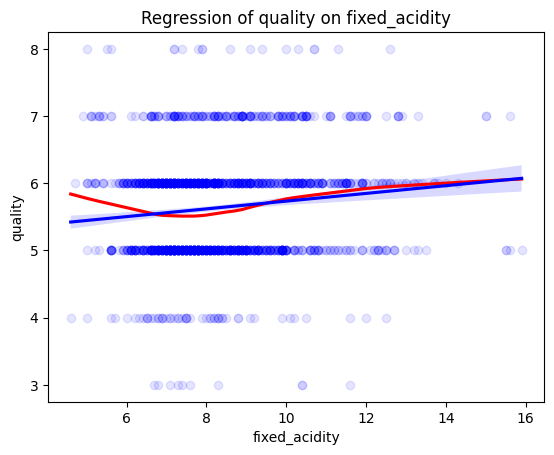

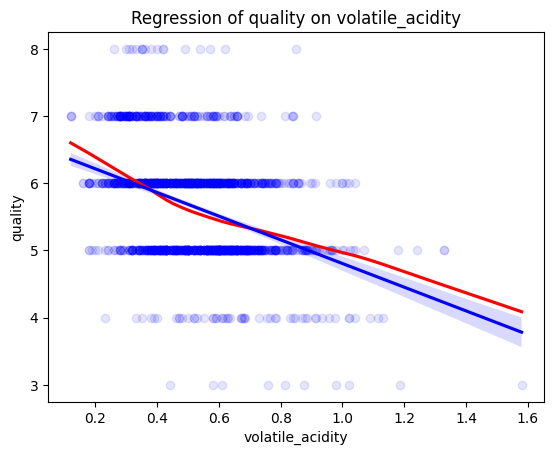

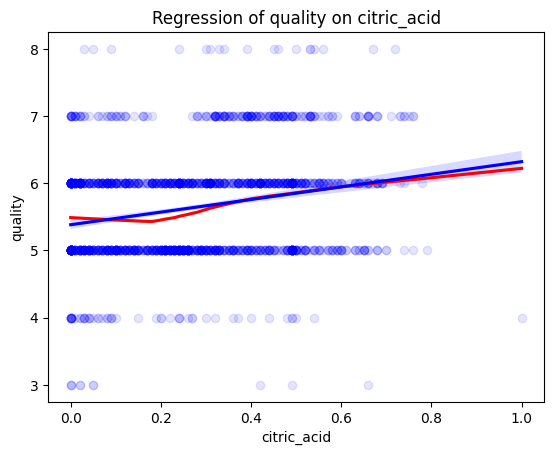

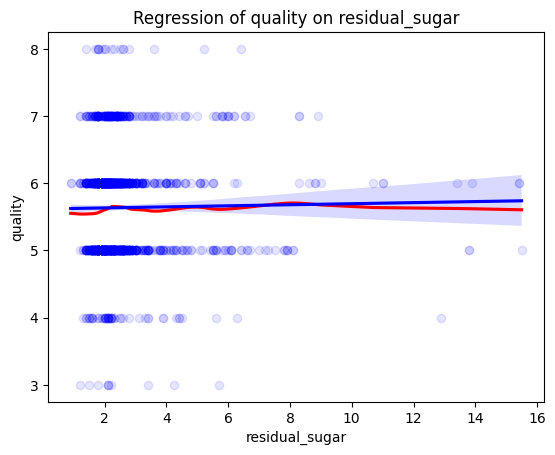

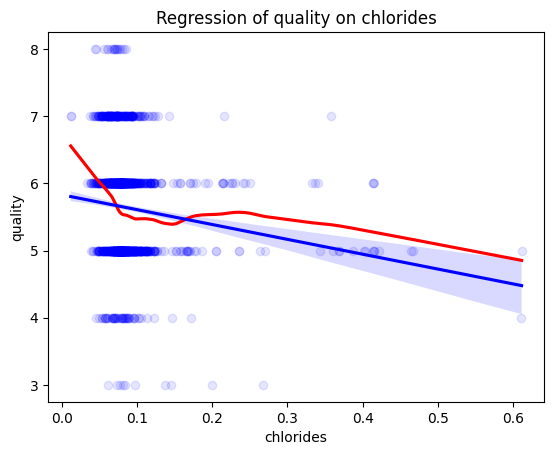

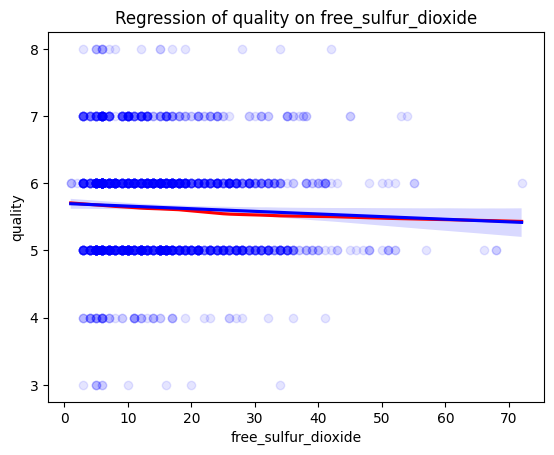

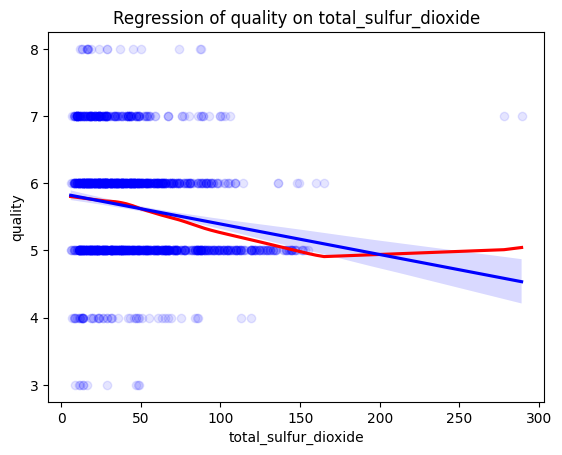

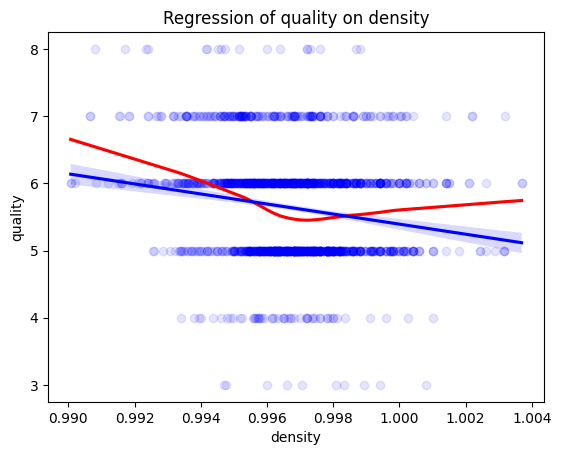

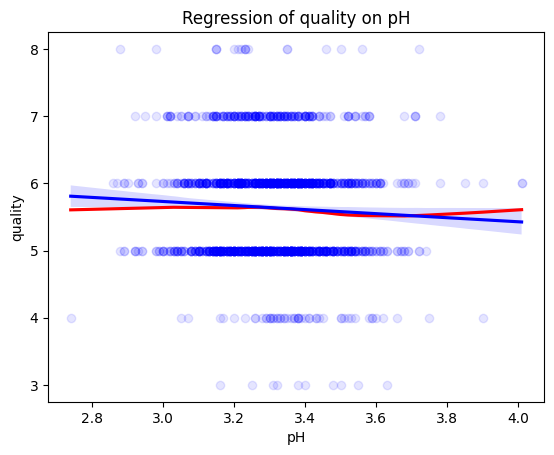

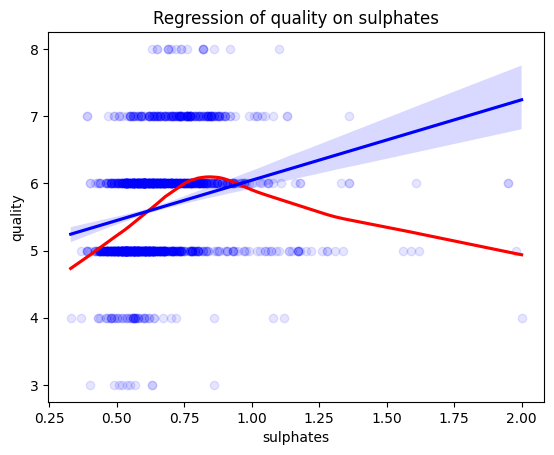

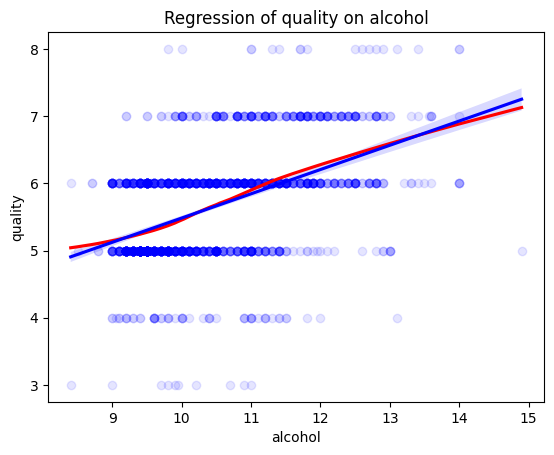

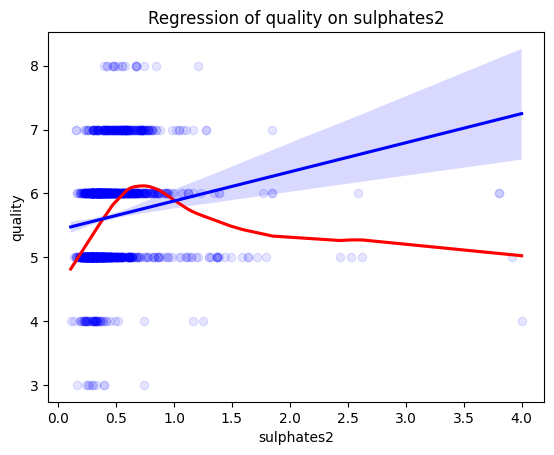

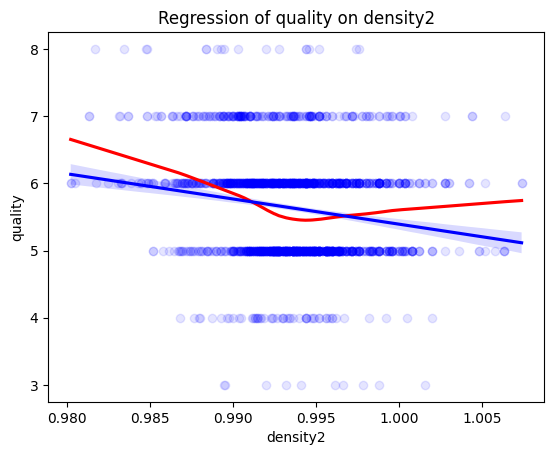

In [8]:
# Plot feature against target including linear analysis
for feature in features:
    sns.regplot(df, x=feature, y="quality", lowess=True, scatter=False, color="red")
    sns.regplot(df, x=feature, y="quality", lowess=False, scatter=True, color="blue", scatter_kws={"alpha": 0.1})
    plt.title(f"Regression of quality on {feature}")
    plt.show()

In [9]:
df["sulphates2"] = df["sulphates"] **2
df["density2"] = df["density"] **2
df = df.drop(["sulphates2", "density2"], axis=1)

# Prepare data for linear model

In [17]:
X = df.drop("quality", axis=1)
y = df["quality"]

X = sm.add_constant(X)

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [19]:
# Standardize features, then add quadratic terms
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features = X_train.drop("const", axis=1).columns.to_list()
X_train[features] = scaler.fit_transform(X_train[features])
X_test[features] = scaler.transform(X_test[features])

X_train["sulphates^2"] = X_train["sulphates"] **2
X_test["sulphates^2"] = X_test["sulphates"] **2
X_train["density^2"] = X_train["density"] **2
X_test["density^2"] = X_test["density"] **2

In [20]:
X_train

,const,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,sulphates^2,density^2
1546,1.0,-0.762578,0.233786,-1.287538,-0.378551,-0.335552,0.101376,-0.629250,-0.546037,0.319613,-0.278402,-0.193189,0.077507,0.298157
244,1.0,3.784715,-1.765741,0.859744,-0.242816,-0.275810,-0.566973,-0.690121,1.723406,-1.564187,1.074380,-1.144078,1.154293,2.970128
1082,1.0,-0.648896,-0.821520,0.143984,-0.514286,-0.315638,1.438075,0.709895,0.034518,0.709364,-0.396035,-0.858811,0.156844,0.001191
610,1.0,0.260563,-1.599114,1.371002,-0.039214,-0.116496,0.865204,0.314238,0.799795,0.514488,-0.690118,-1.144078,0.476263,0.639673
1531,1.0,-1.274149,0.983609,-0.878532,0.164389,-0.156324,-0.280538,-0.568380,-0.250482,1.878619,0.015681,-0.193189,0.000246,0.062741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1033,1.0,-0.478372,0.233786,-0.980783,0.028654,0.002989,-0.185060,-0.598815,-0.456315,-0.070139,-0.396035,-0.003011,0.156844,0.208223
1556,1.0,-0.989943,1.955602,-1.185286,-0.242816,-0.455037,-0.376016,-0.811861,-0.224093,1.423909,-0.572485,-0.478455,0.327739,0.050218
1459,1.0,-0.251008,-1.821284,0.399612,-0.582153,-0.694008,-0.853409,-0.964037,-1.163537,0.059778,0.839114,1.423322,0.704112,1.353818
1480,1.0,-1.558355,0.511498,-1.236412,-0.717888,-0.176238,-0.948887,-1.024907,-0.952426,2.268371,-0.219585,-0.288278,0.048218,0.907115


# Fit OLS

In [29]:
OLS = sm.OLS(y_train, X_train).fit()
print(OLS.summary())

from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE, mean_absolute_percentage_error as MAPE
OLS_preds = OLS.predict(X_test)
performance = pd.DataFrame({"MAE": MAE(y_test, OLS_preds), "MSE": MSE(y_test, OLS_preds), "MAPE": MAPE(y_test, OLS_preds)}, index={"Model": "OLS"})
print(performance)

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     55.63
Date:                Tue, 29 Jul 2025   Prob (F-statistic):          2.20e-114
Time:                        16:41:47   Log-Likelihood:                -1246.3
No. Observations:                1279   AIC:                             2521.
Df Residuals:                    1265   BIC:                             2593.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.6548 

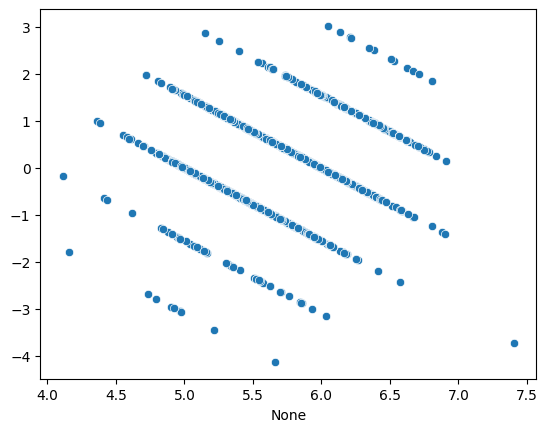

In [32]:
fitted = sns.scatterplot(x=OLS.fittedvalues, y=OLS.resid_pearson)

In [35]:
# Implement ordered model with statsmodels
from statsmodels.miscmodels.ordinal_model import OrderedModel
ordered_model = OrderedModel(y_train, X_train.drop("const", axis=1))
ordered_results = ordered_model.fit(method="bfgs", disp=False)
print(ordered_results.summary())

                             OrderedModel Results                             
Dep. Variable:                quality   Log-Likelihood:                -1229.4
Model:                   OrderedModel   AIC:                             2495.
Method:            Maximum Likelihood   BIC:                             2587.
Date:                Tue, 29 Jul 2025                                         
Time:                        16:45:44                                         
No. Observations:                1279                                         
Df Residuals:                    1261                                         
Df Model:                          13                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
fixed_acidity            0.0069      0.089      0.077      0.938      -0.167       0.181
volatile_acidity      

In [36]:
# Evaluate the ordered model
ordered_preds = ordered_results.predict(X_test.drop("const", axis=1))
ordered_performance = pd.DataFrame({
    "MAE": MAE(y_test, ordered_preds),
    "MSE": MSE(y_test, ordered_preds),
    "MAPE": MAPE(y_test, ordered_preds)
}, index={"Model": "Ordered"})
print(ordered_performance)

ValueError: y_true and y_pred have different number of output (1!=6)